# Task B1
Load the downloaded grayscale image, then:
- Apply the three edge detection methods: Laplacian, Sobel, Canny.
- Display original image and highlighted images to see the difference.

(1327, 1080)


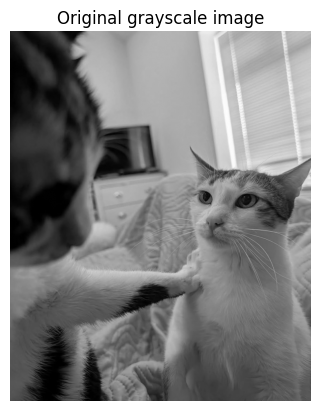

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("input.jpg", cv2.IMREAD_GRAYSCALE)
print(img.shape)

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title("Original grayscale image")

plt.show()

## 1. Laplacian and Sobel edge filtering

In [2]:
def laplacian(img):
    kernel = np.array([
        [0, 1, 0],
        [1, -4, 1],
        [0, 1, 0]
    ])

    output = np.zeros((img.shape[0], img.shape[1]))

    for i in range(1, img.shape[0]-1):
        for j in range(1, img.shape[1]-1):
            patch = img[i-1:i+2, j-1:j+2].astype(np.float32)
            s = np.sum(patch*kernel)
            output[i][j] = s
            
    output = np.clip(output, 0, 255).astype(np.uint8)
    return output

def sobel(img):
    k1 = np.array([
        [1, 0, -1],
        [2, 0, -2],
        [1, 0, -1]
    ])
    k2 = np.array([
        [1, 2, 1],
        [0, 0, 0,],
        [-1, -2, -1]
    ])

    Gx = np.zeros((img.shape[0], img.shape[1]))
    Gy = np.zeros((img.shape[0], img.shape[1]))

    for i in range(1, img.shape[0]-1):
        for j in range(1, img.shape[1]-1):
            patch = img[i-1:i+2, j-1:j+2].astype(np.float32)
            Gx[i][j] = np.sum(patch * k1)
            Gy[i][j] = np.sum(patch * k2)

    Gx = np.array(Gx, dtype=np.float32)
    Gy = np.array(Gy, dtype=np.float32)

    G_mag = np.sqrt(Gx**2 + Gy**2)

    output = np.clip(G_mag, 0, 255).astype(np.uint8)
    return output

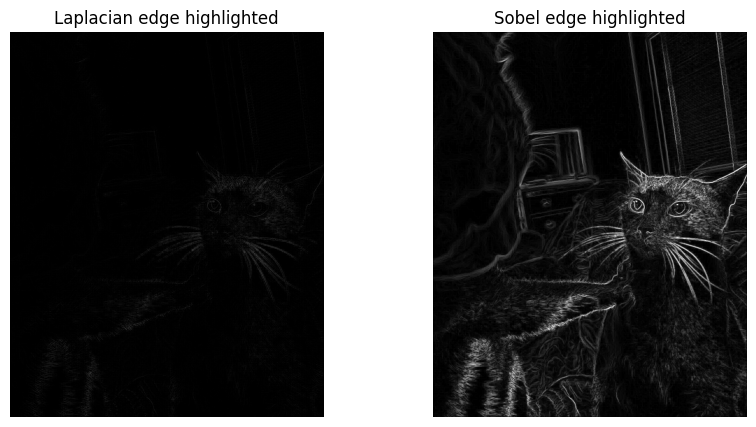

In [3]:
laplacian_highlighted = laplacian(img)
sobel_highlighted = sobel(img)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(laplacian_highlighted, cmap="gray")
axes[0].set_title("Laplacian edge highlighted")
axes[0].axis("off")

axes[1].imshow(sobel_highlighted, cmap="gray")
axes[1].set_title("Sobel edge highlighted")
axes[1].axis("off")

plt.show()

## 2. Canny Edge Detection

### Step 1: Noise Reduction by Gaussian Filtering
- Edge detection use gradient. Gradient are highly sensitive to high-frequency components.
- Noises in image is high frequency. This creates a stronger response from the gradient, hence it might introduce fake edges.
- Use Gaussian filtering to remove these noises.
### Step 2: Apply Sobel Filtering to highlight the edges
### Step 3: Non-Maximum suppression (edge thining)
- First-order derivatives produce thick, blurry bands around an edge because the gradient remains non-zero along the entire "ramp" of an intensity transition.
- To satisfy Canny's criterion of single-pixel-wide responses (A given edge in the image should only be marked once), we must thin these thick bands down to their sharpest local peaks.
- Steps: Compare the edge strength of the current pixel with the edge strength of the pixel in the positive and negative gradient directions. If the edge strength of the current pixel is the largest compared to the other pixels in the mask with the same direction (e.g., a pixel that is pointing in the y-direction will be compared to the pixel above and below it in the vertical axis), the value will be preserved. Otherwise, the value will be suppressed.
    - if the rounded gradient angle is 0° (i.e. the edge is in the north–south direction) the point will be considered to be on the edge if its gradient magnitude is greater than the magnitudes at pixels in the east and west directions,
    - if the rounded gradient angle is 90° (i.e. the edge is in the east–west direction) the point will be considered to be on the edge if its gradient magnitude is greater than the magnitudes at pixels in the north and south directions,
    - if the rounded gradient angle is 135° (i.e. the edge is in the northeast–southwest direction) the point will be considered to be on the edge if its gradient magnitude is greater than the magnitudes at pixels in the north-west and south-east directions,
    - if the rounded gradient angle is 45° (i.e. the edge is in the northwest–southeast direction) the point will be considered to be on the edge if its gradient magnitude is greater than the magnitudes at pixels in the north-east and south-west directions.
### Step 4: Hysteresis Thresholding
Instead of using one simple cutoff threshold, Canny uses two thresholds (High and Low) to solve the problem of fractured edges:
- Pixels above the High threshold are instantly locked in as strong, permanent edges.
- Pixels below the Low threshold are instantly thrown away.
- Pixels between the two are marked as weak edges. They only survive and get kept if they are physically connected to a strong edge pixel. This allows the algorithm to trace continuous contours without breaking up due to minor lighting shifts.

In [5]:
def Canny_detector(img, weak_th=None, strong_th=None):
    gx = cv2.Sobel(np.float32(img), cv2.CV_64F, 1, 0, 3)
    gy = cv2.Sobel(np.float32(img), cv2.CV_64F, 0, 1, 3)

    mag, ang = cv2.cartToPolar(gx, gy, angleInDegrees=True)

    height, width = img.shape

    mag_max = np.max(mag)
    if weak_th is None:
        weak_th = mag_max * 0.1
    if strong_th is None:
        strong_th = mag_max * 0.5

   
    nms = np.zeros_like(mag)

    for i_x in range(1, width-1):
        for i_y in range(1, height-1):

            grad_ang = ang[i_y, i_x]
            grad_ang = grad_ang % 180

            if (0 <= grad_ang < 22.5) or (157.5 <= grad_ang <= 180):
                before = mag[i_y, i_x - 1]
                after  = mag[i_y, i_x + 1]

            elif (22.5 <= grad_ang < 67.5):
                before = mag[i_y - 1, i_x + 1]
                after  = mag[i_y + 1, i_x - 1]

            elif (67.5 <= grad_ang < 112.5):
                before = mag[i_y - 1, i_x]
                after  = mag[i_y + 1, i_x]

            else:  # 112.5 - 157.5
                before = mag[i_y - 1, i_x - 1]
                after  = mag[i_y + 1, i_x + 1]

            if mag[i_y, i_x] >= before and mag[i_y, i_x] >= after:
                nms[i_y, i_x] = mag[i_y, i_x]
            else:
                nms[i_y, i_x] = 0

    result = np.zeros_like(nms)

    strong = 255
    weak = 75

    for i_x in range(width):
        for i_y in range(height):
            val = nms[i_y, i_x]

            if val >= strong_th:
                result[i_y, i_x] = strong
            elif val >= weak_th:
                result[i_y, i_x] = weak
            else:
                result[i_y, i_x] = 0

    return result

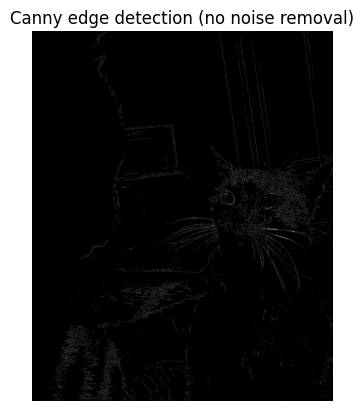

In [6]:
canny_highlighted = Canny_detector(img)
plt.imshow(canny_highlighted, cmap="gray")
plt.axis("off")
plt.title("Canny edge detection (no noise removal)")

plt.show()

# Task B2
Add Gaussian noise to the downloaded grayscale image, then:
- Apply the three edge detection methods: Laplacian, Sobel, Canny.
- Smooth the noisy image using Gaussian blur.
- Apply Sobel, Laplacian and Canny again to the smoothing noisy image.
- Compare the edge detection results before and after smoothing.

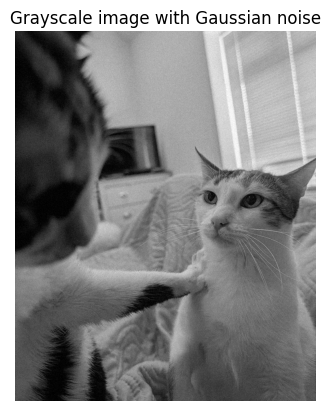

In [7]:
def gauss_noise(img):
    row,col= img.shape
    mean = 0
    var = 100
    sigma = var**0.5
    gauss = np.random.normal(mean,sigma,(row,col))
    gauss = gauss.reshape(row,col)
    noisy = img + gauss
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)
    return noisy

img_gauss_noise = gauss_noise(img)

plt.imshow(img_gauss_noise, cmap="gray")
plt.axis("off")
plt.title("Grayscale image with Gaussian noise")

plt.show()

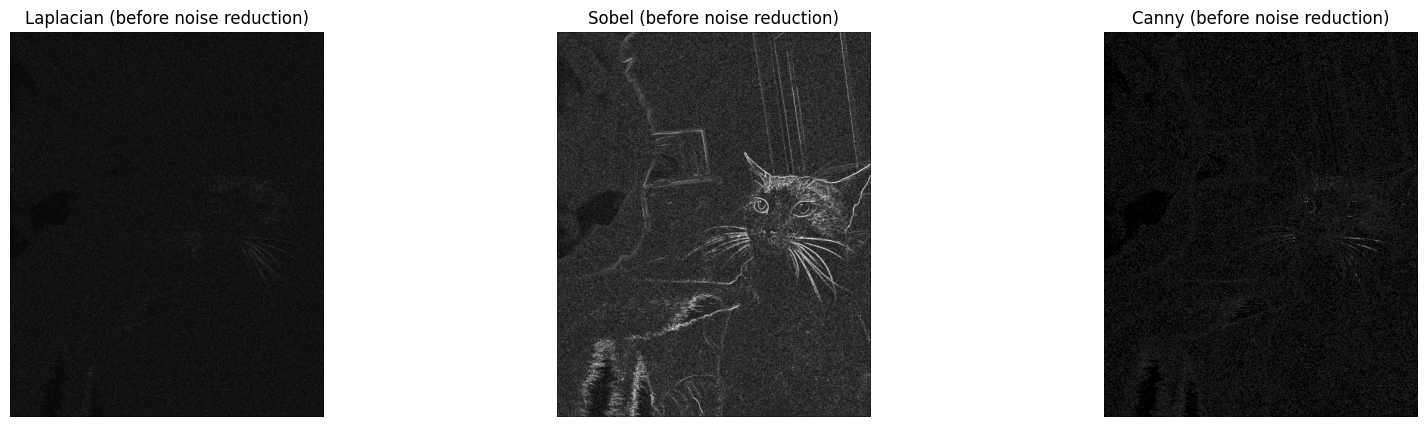

In [8]:
laplacian_highlighted = laplacian(img_gauss_noise)
sobel_highlighted = sobel(img_gauss_noise)
canny_highlighted = Canny_detector(img_gauss_noise)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].imshow(laplacian_highlighted, cmap="gray")
axes[0].set_title("Laplacian (before noise reduction)")
axes[0].axis("off")

axes[1].imshow(sobel_highlighted, cmap="gray")
axes[1].set_title("Sobel (before noise reduction)")
axes[1].axis("off")

axes[2].imshow(canny_highlighted, cmap="gray")
axes[2].set_title("Canny (before noise reduction)")
axes[2].axis("off")

plt.show()

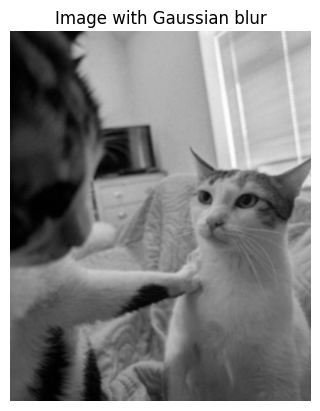

In [9]:
# Applying Gaussian blur
blurry = cv2.GaussianBlur(img_gauss_noise, (15, 15), 0)

plt.imshow(blurry, cmap="gray")
plt.title("Image with Gaussian blur")
plt.axis("off")

plt.show()

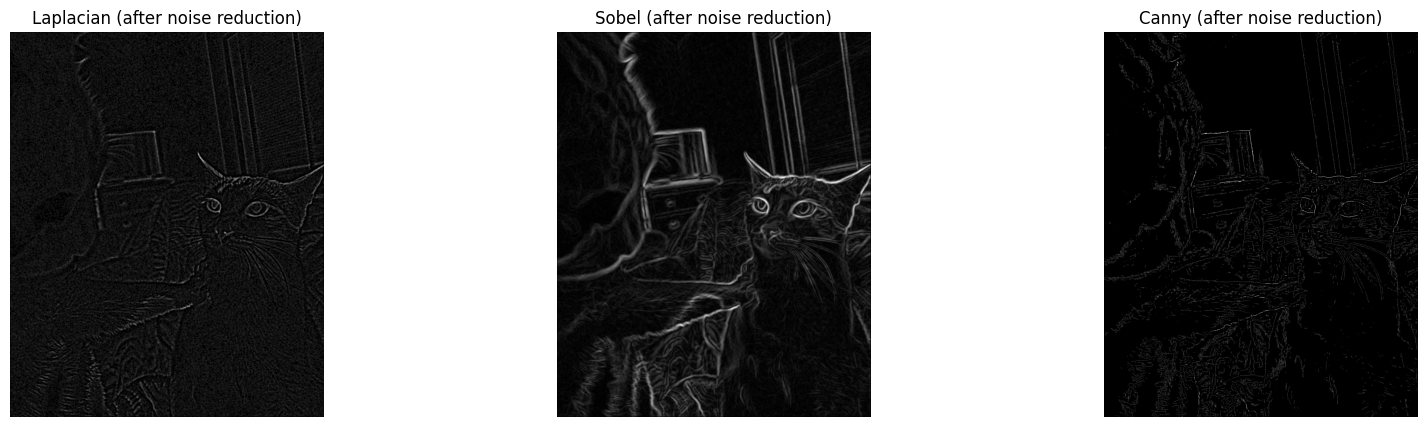

In [10]:
laplacian_highlighted = laplacian(blurry)
sobel_highlighted = sobel(blurry)
canny_highlighted = Canny_detector(blurry)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].imshow(laplacian_highlighted, cmap="gray")
axes[0].set_title("Laplacian (after noise reduction)")
axes[0].axis("off")

axes[1].imshow(sobel_highlighted, cmap="gray")
axes[1].set_title("Sobel (after noise reduction)")
axes[1].axis("off")

axes[2].imshow(canny_highlighted, cmap="gray")
axes[2].set_title("Canny (after noise reduction)")
axes[2].axis("off")

plt.show()

Comparisons:
- Before Gaussian smoothing: After apply the edge detections, some important structures of the image is completely lost, or fade into the noises (for example the cat's ears is lost in Laplacian and Canny). For the Sobel edge detection, it shows all the noises, which is not the goal of edge detection.
- After Gaussian smoothing: Structure of image now can be seen more clearly (the cat's eyes, ears, legs are now visible). For Sobel, now it is cleaner as noise are removed.
- The Trade-off: While the shapes of the cats looks clearly now, the lines are thicker and less precise than they would be on a clean image. The $15 \times 15$ kernel successfully removed the noise, but it smeared the spatial boundaries.

# Task B3: Segmentation - Global Thresholding
Perform image segmentation on the downloaded grayscale image using thresholding by doing the following tasks:
- Display the downloaded grayscale image and its histogram.
- Select two manual threshold values.
- Apply global thresholding for each selected threshold.
- Apply Otsu thresholding.
- Compare the results.

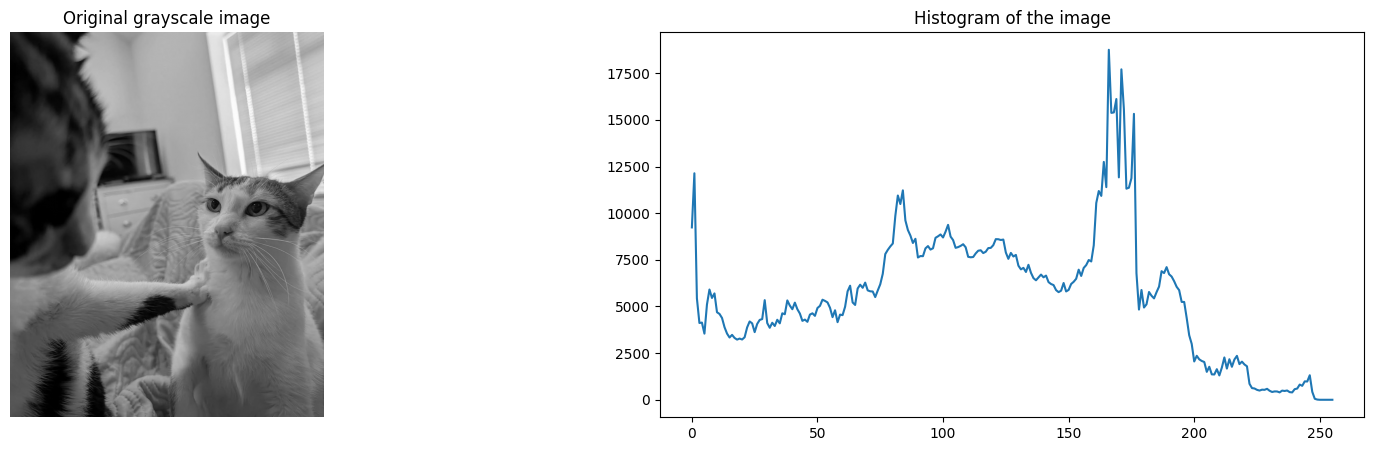

In [35]:
histg = cv2.calcHist([img],[0],None,[256],[0,256])

fig, axes = plt.subplots(1, 2, figsize=(20, 5))

axes[0].imshow(img, cmap="gray")
axes[0].axis("off")
axes[0].set_title("Original grayscale image")

axes[1].plot(histg)
axes[1].set_title("Histogram of the image")
plt.show()

In [38]:
def thresholding(img, stop_criteria):
    output = img.copy()
    output = output.astype(np.float128)
    T = np.mean(output)
    count = 0
    while True:
        count += 1
        G1 = output[output > T]
        G2 = output[output <= T]
        if G1.size > 0:
            mu1 = np.mean(G1)
        else:
            mu1 = 0
        if G2.size > 0:
            mu2 = np.mean(G2)
        else:
            mu2 = 0
        T_new = (mu1+mu2)/2.0

        if abs(T - T_new) < stop_criteria:
            T = T_new
            break

        T = T_new

    for i in range(output.shape[0]):
        for j in range(output.shape[1]):
            if output[i][j] > T:
                output[i][j] = 255
            else:
                output[i][j] = 0

    output = np.clip(output, 0, 255).astype(np.uint8)
    print(f"Thresholding stops after {count} iterations with threshold value: {int(T)}")
    return output

Thresholding stops after 2 iterations with threshold value: 112


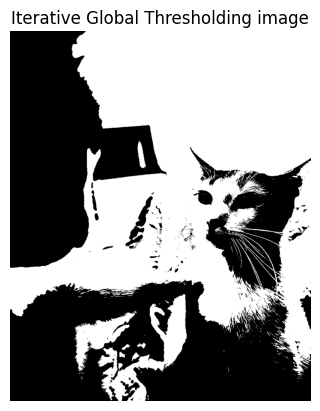

In [39]:
bw = thresholding(img, 1)

plt.imshow(bw, cmap="gray")
plt.axis("off")
plt.title("Iterative Global Thresholding image")

plt.show()

Calculated Otsu threshold value: 111


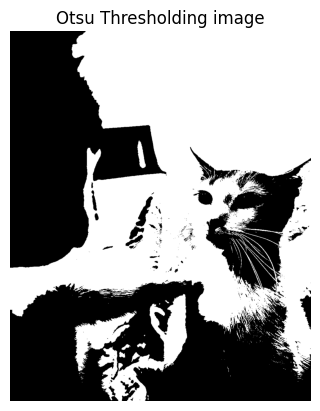

In [41]:
# Otsu thresholding
ret, otsu_thresh = cv2.threshold(
    img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print("Calculated Otsu threshold value:", int(ret))
plt.imshow(otsu_thresh, cmap="gray")
plt.axis("off")
plt.title("Otsu Thresholding image")

plt.show()

Result comparison: There are almost no differences in the results of the 2 thresholding algorithms. Final threshold value of Global Thresholding is 112, while final threshold value of Otsu Thresholding is 111.

# Task B4
Perform the morphological operations in Part A again but by coding.

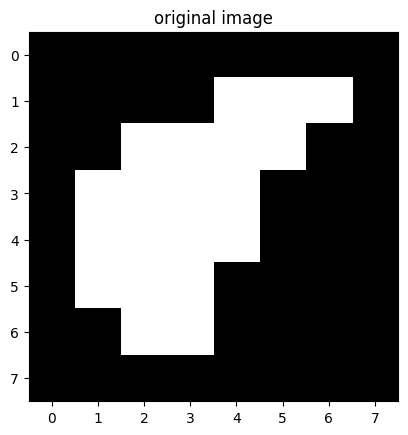

In [54]:
img = [[0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 1, 1, 0],
       [0, 0, 1, 1, 1, 1, 0, 0],
       [0, 1, 1, 1, 1, 0, 0, 0],
       [0, 1, 1, 1, 1, 0, 0, 0],
       [0, 1, 1, 1, 0, 0, 0, 0],
       [0, 0, 1, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0]]

struct_element = [[0, 1, 0],
                  [1, 1, 1],
                  [0, 1, 0]]

img_display = img.copy()
img_display = np.array(img_display, dtype=np.uint8)
for i in range(img_display.shape[0]):
        for j in range(img_display.shape[1]):
            if img_display[i][j] == 1:
                img_display[i][j] = 255
kernel = np.array(struct_element, dtype=np.uint8)


def show_img(img, title):
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.show()

show_img(img_display, "original image")

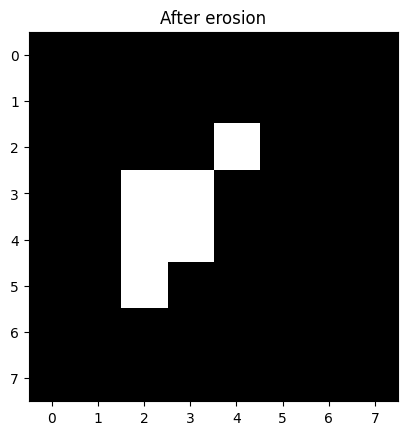

In [61]:
img_erosion = cv2.erode(img_display, kernel, iterations=1, borderType=cv2.BORDER_CONSTANT, borderValue=0)
show_img(img_erosion, "After erosion")

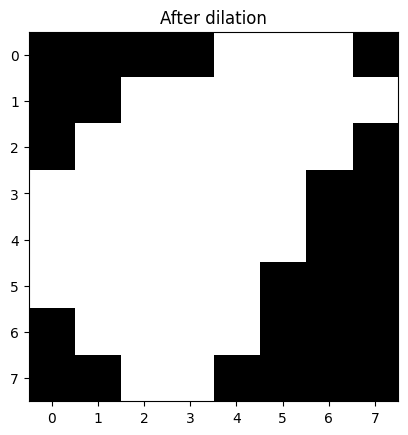

In [62]:
img_dilation = cv2.dilate(img_display, kernel, iterations=1, borderType=cv2.BORDER_CONSTANT, borderValue=0)
show_img(img_dilation, "After dilation")

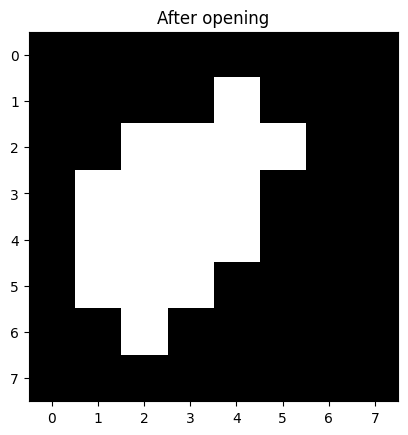

In [63]:
img_opening = cv2.dilate(img_erosion, kernel, iterations=1, borderType=cv2.BORDER_CONSTANT, borderValue=0)
show_img(img_opening, "After opening")

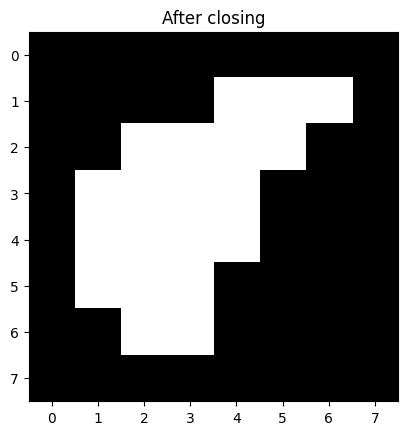

In [64]:
img_closing = cv2.erode(img_dilation, kernel, iterations=1, borderType=cv2.BORDER_CONSTANT, borderValue=0)
show_img(img_closing, "After closing")